In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
# plt.rcParams['font.size']=14
# plt.rcParams['lines.markersize']=7
# plt.rcParams['axes.grid']=True
# plt.rcParams['figure.figsize'] = (13,5)

In [ ]:
from sklearn import datasets
dir(datasets)

In [4]:
wine=datasets.load_wine()
wine.keys()


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

In [7]:
x = pd.DataFrame(wine.data, columns=wine.feature_names)

In [9]:
x.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [10]:
x.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [8]:
wine.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

__But this is unsupervised learning so lets drop targets__

#### Standard scaling for PCA

In [11]:
wXs = StandardScaler().fit_transform(x) #x-mean/std

#### Note that this is a small dataset, and PCA may not benefit

In [12]:
pca = PCA(n_components=2)
wXpca = pca.fit_transform(wXs)

In [13]:
wXpca[:5]

array([[ 3.31675081,  1.44346263],
       [ 2.20946492, -0.33339289],
       [ 2.51674015,  1.0311513 ],
       [ 3.75706561,  2.75637191],
       [ 1.00890849,  0.86983082]])

#### Finding the number of clusters with Elbow plot

In [ ]:
# normal distri===mean, std=1

# minmaxscaler===> 5, 10 x-xmin/xmax-xmin

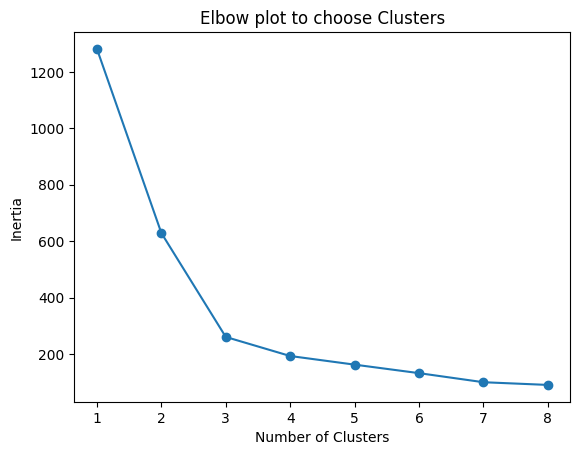

In [14]:
inertia_list=[]

cluster_options =np.arange(1,9)

for num_cluster in cluster_options:
    model=KMeans(num_cluster)
    model.fit(wXpca)
    inertia_list.append(model.inertia_)

plt.plot(cluster_options, inertia_list, '-o')
plt.title('Elbow plot to choose Clusters')
plt.ylabel('Inertia')
plt.xlabel('Number of Clusters')
plt.xticks(cluster_options)
plt.show()

In [15]:
model=KMeans(n_clusters=3, n_init= 20, max_iter=1000, random_state=2)
model.fit(wXpca)

KMeans(max_iter=1000, n_clusters=3, n_init=20, random_state=2)

In [16]:
model.predict(wXpca)[:5]

array([0, 0, 0, 0, 0], dtype=int32)

In [17]:
dir(model)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_algorithm',
 '_build_request_for_signature',
 '_check_feature_names',
 '_check_mkl_vcomp',
 '_check_n_features',
 '_check_params_vs_input',
 '_check_test_data',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_estimator_type',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_tags',
 '_init_centroids',
 '_more_tags',
 '_n_features_out',
 '_n_init',
 '_n_threads',
 '_parameter_constraints',
 '_re

In [18]:
centroids = model.cluster_centers_
centroids

array([[ 2.26614991,  0.86559213],
       [-2.74392982,  1.2141906 ],
       [-0.16278513, -1.76758824]])

In [26]:
label  =model.labels_

### <font color =darkred> The below analysis is just for illustration we would'nt have labels in real life scenario, as this is unsupervised learning!

In [24]:
wy = wine.target
wy

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

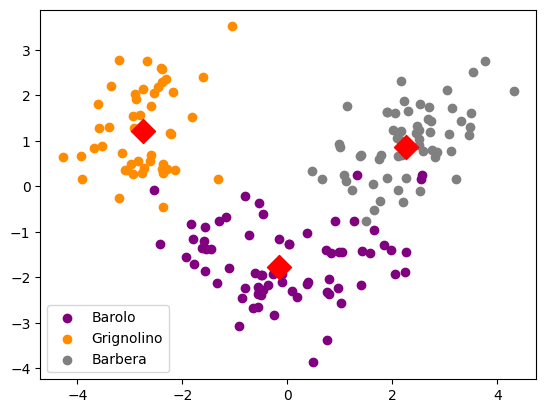

In [25]:

centroids = model.cluster_centers_
plt.scatter(wXpca[:, 0][wy ==1], wXpca[:, 1][wy ==1], c='purple', label = 'Barolo')
plt.scatter(wXpca[:, 0][wy ==2], wXpca[:, 1][wy ==2], c='darkorange', label = 'Grignolino')
plt.scatter(wXpca[:, 0][wy ==0], wXpca[:, 1][wy ==0], c='grey', label = 'Barbera')
plt.scatter(centroids[:, 0], centroids[:, 1], marker='D', s=150, c= 'r')
plt.legend()
plt.show()

---
---

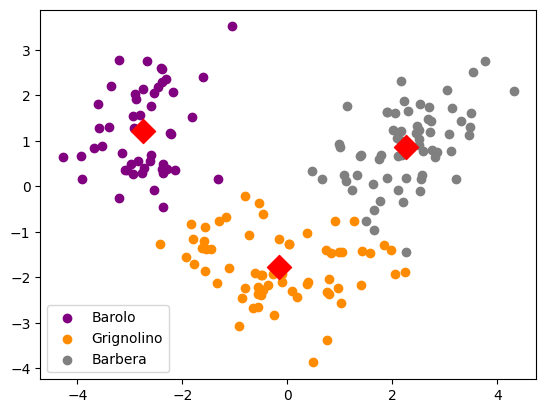

In [27]:

centroids = model.cluster_centers_
plt.scatter(wXpca[:, 0][label ==1], wXpca[:, 1][label ==1], c='purple', label = 'Barolo')
plt.scatter(wXpca[:, 0][label ==2], wXpca[:, 1][label ==2], c='darkorange', label = 'Grignolino')
plt.scatter(wXpca[:, 0][label ==0], wXpca[:, 1][label ==0], c='grey', label = 'Barbera')
plt.scatter(centroids[:, 0], centroids[:, 1], marker='D', s=150, c= 'r')
plt.legend()
plt.show()